# Movie Data Project 

In this project, I will extract data from ***TMDB***'s movies API, perform transformations, and conduct data analaysis to derive insights.

In [5]:
# Import packages all necessary packages
from dotenv import load_dotenv
import os
import sys
import requests
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from datetime import datetime


# adding the path of the src folder to import cleaning functions script
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
sys.path.append('src')

import main_utils as main
from plot_utils import plot_data



<hr>

## STEP 1: API Data Extraction

In [ ]:
''' load .env file in this directory'''
load_dotenv()


'''get api key and save the base url'''
api_key = os.getenv('TMDB_API_KEY')

url = 'https://api.themoviedb.org/3/movie'

In [ ]:
'''list of movies to fetch from API'''

movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397, 
             420818, 24428, 168259, 99861, 284054, 12445, 181808, 
             330457, 351286, 109445, 321612, 260513]

In [ ]:
'''fetch and save movies to movies variable'''

movies = main.api_extract(url, api_key, movie_ids)

In [ ]:
'''confirming if all movies were fetched successfully'''

print(f'Movie IDs: {len(movie_ids)} || Exctracted Items: {len(movies)}')


**Movie id 0 was not found.** All movies were fetched successfully and saved to *movies* variable.

<hr>

### 1a Exploring the fetched data

API data structure is typically in JSON format. I am expecting same for these fetched data. 
- Lists nested in dictionaries
- Dictionaries nested in lists

I will explore briefly the structure of this data

In [ ]:
'''Check first item in the movies list'''

movies[0]

Fetched data indeed fits the assumptions. Lists nested in Dictionaries. This provides a chance to have a glance at the headers(***keys***) of the data to check if all columns were fetched. 

In [ ]:
'''Checking the keys of the dictionaries'''

print(movies[0].keys())
print(f'\nThere are {len(movies[0].keys())} column headers in the dataset.')

<hr>

### 1b. Covert List to DataFrame

I will convert the movies data into a pandas dataframe to be more structured

In [ ]:
'''Convert lists to DataFrame'''

df_movies = pd.DataFrame(movies)

### 1c. Explore the DataFrame

In [ ]:
'''Explore dataframe'''

# column names
df_movies.columns

In [68]:
# display all columns columns to none
pd.set_option('display.max_columns', None)


# Set maximum column width to 500
pd.set_option('display.max_colwidth', 25)


In [ ]:
'''Explore first 2 records'''

df_movies.head(2)

**There are many columns that have nested lists and dictionaries.**

This is data is as dirty is it can be. 

### 1d. Export Data
Export or save this unprocessed ***(raw)*** data to the *data/* directory

In [ ]:
'''Export file as csv to /data/raw directory'''

today = datetime.today().strftime('%Y-%m-%d')  # add datetime function to indicate day the file was saved


df_movies.to_csv(f'../data/raw/raw_csv_data_{today}.csv', index=False)

## STEP 2: Data Cleaning and Preprocessing

In this phase, I do the *data cleaning and processing*. From exploring the dataset, dropping irrelevant columns, filtering and more.

* The data was fetched from an API, therefore it is consistent with JSON formats. Nested data structures.
* Normally, I'd create a copy of the dataset and work with the copy just in case something goes wrong but in this case, I will not be doing that.

### 2a. Data Preparation and Cleaning

In [4]:
'''read raw data'''

df_movies = pd.read_csv('../data/raw/raw_csv_data_2025-04-18.csv')

In [5]:
'''Check header of the dataframe'''

df_movies.head(0)

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,credits


In [24]:
'''Check the number of columns'''

print(f'There are {len(df_movies.columns)} columns in the dataset')

There are 27 columns in the dataset


In [6]:
'''View first two records'''
df_movies.head(2)

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,credits
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,['US'],en,...,2799439100,181,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.237,26235,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",https://www.avatar.com/movies/avatar,19995,tt0499549,['US'],en,...,2923706026,162,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.588,32147,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."


### 2b. Drop Unused Columns

In [7]:
'''drop irrelevant columns'''

df_movies = df_movies.drop(columns=['adult', 'imdb_id', 'original_title', 'video', 
                                    'homepage','backdrop_path', 'origin_country'])

### 2c. Evaluate JSON columns

In [8]:
'''check columns with unusual structure'''

df_movies[['belongs_to_collection', 'genres', 'production_countries',
           'production_companies', 'spoken_languages', 'credits']].head(2)

,belongs_to_collection,genres,production_countries,production_companies,spoken_languages,credits
0,"{'id': 86311, 'name': 'The Avengers Collection...","[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'english_name': 'English', 'iso_639_1': 'en'...","{'cast': [{'adult': False, 'gender': 2, 'id': ..."
1,"{'id': 87096, 'name': 'Avatar Collection', 'po...","[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...","[{'iso_3166_1': 'US', 'name': 'United States o...","[{'id': 444, 'logo_path': None, 'name': 'Dune ...","[{'english_name': 'English', 'iso_639_1': 'en'...","{'cast': [{'adult': False, 'gender': 2, 'id': ..."


In [9]:
'''Explore the columns briefly'''

df_movies[['belongs_to_collection', 'genres', 'production_countries', 'production_companies', 
           'spoken_languages', 'credits']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   belongs_to_collection  16 non-null     object
 1   genres                 18 non-null     object
 2   production_countries   18 non-null     object
 3   production_companies   18 non-null     object
 4   spoken_languages       18 non-null     object
 5   credits                18 non-null     object
dtypes: object(6)
memory usage: 996.0+ bytes


There are only 2 null values in the columns, **belongs_to_collection** in specific. The others do not have any non-null values.

In [10]:
'''Check the type of the first value in the column.'''

print(df_movies[['belongs_to_collection','genres','production_companies',
                 'production_countries','spoken_languages', 'credits' ]].iloc[0])


belongs_to_collection    {'id': 86311, 'name': 'The Avengers Collection...
genres                   [{'id': 12, 'name': 'Adventure'}, {'id': 878, ...
production_companies     [{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...
production_countries     [{'iso_3166_1': 'US', 'name': 'United States o...
spoken_languages         [{'english_name': 'English', 'iso_639_1': 'en'...
credits                  {'cast': [{'adult': False, 'gender': 2, 'id': ...
Name: 0, dtype: object


These data are all of *string* datatype because they were converted into the dataframe. But are obviously **Dictionaries**, and **Lists**.

* ***belongs_to_collection*** and ***credits*** are dictionaries
* The remaining four are all lists with dictionaries nested.

### 2d. Extract Key Data Points

***Clean JSON like columns and seperate multiple values with |***

In [11]:
''' 01. Extract Collection Names from belongs_to_collection'''

# Columns to extract with is_list=True
list_columns = ['genres', 'production_companies', 'production_countries', 'spoken_languages']

# Apply extraction for list-based columns
for col in list_columns:
    df_movies[col] = df_movies.apply(lambda row: main.extract_from_column(row, col, is_list=True), axis=1)

# Extract franchise info (single value or None)
df_movies['franchise'] = df_movies.apply(
    lambda row: main.extract_from_column(row, 'belongs_to_collection') or 'Standalone', axis=1
)


In [12]:
print('\nUpdated columns')
df_movies[['title', 'franchise', 'genres', 'production_companies', 'production_countries', 'spoken_languages']].head()


Updated columns


,title,franchise,genres,production_companies,production_countries,spoken_languages
0,Avengers: Endgame,The Avengers Collection,Adventure|Science Fiction|Action,Marvel Studios,United States of America,English|日本語|
1,Avatar,Avatar Collection,Action|Adventure|Fantasy|Science Fiction,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,English|Español
2,Star Wars: The Force Awakens,Star Wars Collection,Adventure|Action|Science Fiction,Lucasfilm Ltd.|Bad Robot,United States of America,English
3,Avengers: Infinity War,The Avengers Collection,Adventure|Action|Science Fiction,Marvel Studios,United States of America,English|
4,Titanic,Standalone,Drama|Romance,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,English|Français|Deutsch|svenska|Italiano|Pусский


Ideally, I'd create a new column for the extracted data. But I made an exception today

In [13]:
'''
    Checking the columns to find how many columns I have still. 
    Before the cleaning process, the dataset had 27 columns. 
'''
print(f'There are {len(df_movies.columns)} columns in the dataset after first phase of cleaning')


There are 21 columns in the dataset after first phase of cleaning


 <hr>

***Extract New Columns From Credits***

In [14]:
'''Examine the credits column'''
df_movies['credits'].head(1)

0    {'cast': [{'adult': False, 'gender': 2, 'id': ...
Name: credits, dtype: object

In [15]:
'''Extract cast, cast_size, crew_size, directors from the credits'''

#extract engineered columns into credits_info
credits_info = df_movies.apply(main.extract_credits, axis=1)


# add engineered columns to existing df_movies
df_movies = pd.concat([df_movies, credits_info], axis=1)


'''check out new columns'''

print('\nNew columns created')
df_movies[['title', 'cast_size', 'crew_size', 'directors', 'cast']].head()


New columns created


,title,cast_size,crew_size,directors,cast
0,Avengers: Endgame,105,593,Joe Russo|Anthony Russo,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...
1,Avatar,65,986,James Cameron,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...
2,Star Wars: The Force Awakens,182,257,J.J. Abrams,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...
3,Avengers: Infinity War,69,724,Anthony Russo|Joe Russo,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...
4,Titanic,116,258,James Cameron,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...


In [16]:
'''Drop credits column after new features extracted'''

df_movies = df_movies.drop(columns='credits')

### 2e. Convert of columns and datatypes

In [17]:
df_movies.head(2)

,belongs_to_collection,budget,genres,id,original_language,overview,popularity,poster_path,production_companies,production_countries,...,status,tagline,title,vote_average,vote_count,franchise,cast_size,crew_size,directors,cast
0,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,Adventure|Science Fiction|Action,299534,en,After the devastating events of Avengers: Infi...,26.4337,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,...,Released,Avenge the fallen.,Avengers: Endgame,8.237,26235,The Avengers Collection,105,593,Joe Russo|Anthony Russo,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...
1,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,Action|Adventure|Fantasy|Science Fiction,19995,en,"In the 22nd century, a paraplegic Marine is di...",31.5076,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,...,Released,Enter the world of Pandora.,Avatar,7.588,32147,Avatar Collection,65,986,James Cameron,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...


In [18]:
'''Convert release_date to date time'''

main.convert_datetime(df_movies, ['release_date'])

In [19]:
''' round up popularity and vote average figure to 2 decimal place '''

main.round_to_two(df_movies, ['popularity', 'vote_average'])

In [20]:
'''convert revenue and budget to million_usd'''

main.convert_to_millions(df_movies, ['budget', 'revenue'])

In [21]:
'''filter dataframe by 'realeased' status and drop status'''

df_movies = df_movies[df_movies['status'] == 'Released']

In [22]:
'''drop belongs to collection columns'''

df_movies = df_movies.drop(columns = ['belongs_to_collection', 'status', 'budget', 'revenue'])

In [23]:
'''View dataframe'''

df_movies.head(2)

,genres,id,original_language,overview,popularity,poster_path,production_companies,production_countries,release_date,runtime,...,title,vote_average,vote_count,franchise,cast_size,crew_size,directors,cast,budget_million_usd,revenue_million_usd
0,Adventure|Science Fiction|Action,299534,en,After the devastating events of Avengers: Infi...,26.43,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,181,...,Avengers: Endgame,8.24,26235,The Avengers Collection,105,593,Joe Russo|Anthony Russo,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,356.0,2799.44
1,Action|Adventure|Fantasy|Science Fiction,19995,en,"In the 22nd century, a paraplegic Marine is di...",31.51,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,162,...,Avatar,7.59,32147,Avatar Collection,65,986,James Cameron,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,237.0,2923.71


In [25]:
col_names = list(df_movies.columns)

for col in col_names:
    print(f'{col}', end=" ")
    
print(f'\nThere are {len(df_movies.columns)} now')

genres id original_language overview popularity poster_path production_companies production_countries release_date runtime spoken_languages tagline title vote_average vote_count franchise cast_size crew_size directors cast budget_million_usd revenue_million_usd 
There are 22 now


In [26]:
'''reorder columns and reset index'''

df_movies = df_movies[['id', 'title', 'tagline', 'release_date', 'genres', 'franchise',
                       'original_language', 'budget_million_usd', 'revenue_million_usd', 'production_companies',
                       'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime','overview', 
                       'spoken_languages', 'poster_path', 'cast', 'cast_size', 'directors', 'crew_size']]

In [27]:
'''reset the index'''
df_movies = df_movies.reset_index(drop=True)

In [64]:
'''save cleaned data to /data/processed directory'''

today = datetime.today().strftime('%Y-%m-%d')

df_movies.to_csv(f'../data/processed/processed_csv_data_{today}.csv', index=False) # add date to the saved file 

<hr>

# STEP 3: KPI Performance and Analysis

### 3a. Movie Performance

In [15]:
'''Top 3 movies with the highest revenue recorded'''

highest_revenue = df_movies.sort_values(by='revenue_million_usd', ascending=False).head(3)


print('\nTop 3 Highest Revenue Movies')
highest_revenue[['title', 'revenue_million_usd', 'production_companies', 'franchise', 'release_date']]


Top 3 Highest Revenue Movies


,title,revenue_million_usd,production_companies,franchise,release_date
1,Avatar,2923.71,Dune Entertainment|Lightstorm Entertainment|20...,Avatar Collection,2009-12-15
0,Avengers: Endgame,2799.44,Marvel Studios,The Avengers Collection,2019-04-24
4,Titanic,2264.16,Paramount Pictures|20th Century Fox|Lightstorm...,Standalone,1997-11-18


**3 Movies with the highest revenue generated are:**
* Avatar: Enter the World of Pandora
* Avengers: Endgame
* Titanic

<hr>

In [17]:
'''Top 3 Movies with the highest Budget'''

highest_budget = df_movies.sort_values(by='budget_million_usd', ascending=False).head(3)


print('\nTop 3 Movies with High Budgets')
highest_budget[['title', 'budget_million_usd', 'production_companies', 'franchise', 'release_date']]


Top 3 Movies with High Budgets


,title,budget_million_usd,production_companies,franchise,release_date
9,Avengers: Age of Ultron,365.0,Marvel Studios,The Avengers Collection,2015-04-22
0,Avengers: Endgame,356.0,Marvel Studios,The Avengers Collection,2019-04-24
3,Avengers: Infinity War,300.0,Marvel Studios,The Avengers Collection,2018-04-25


**Top 3 Movies with High budgets**
* Avengers: Age of Ultron with 365M at the top
* Avengers: Endgame with 356M at second
* Avengers: Infinity War 300M

These top 3 movies are all part of the Marvel Avengers franchise. Marvel allocates a lot of money for the Avengers collections of movies.

<hr>

In [23]:
'''Top 3 movies with the Highest Profit generated'''


# new column profit
df_movies['profit'] = (df_movies['revenue_million_usd'] - df_movies['budget_million_usd']).round(2)


highest_profit = df_movies.sort_values(by='profit', ascending=False).head(3)



print('\nTop 3 Movies with Highest Profit')
highest_profit[['title', 'profit', 'production_companies', 'franchise', 'release_date']]


Top 3 Movies with Highest Profit


,title,profit,production_companies,franchise,release_date
1,Avatar,2686.71,Dune Entertainment|Lightstorm Entertainment|20...,Avatar Collection,2009-12-15
0,Avengers: Endgame,2443.44,Marvel Studios,The Avengers Collection,2019-04-24
4,Titanic,2064.16,Paramount Pictures|20th Century Fox|Lightstorm...,Standalone,1997-11-18


**The top 3 movies with the highest profit**
* Avatar: Enter the world of Pandora tops wiith 2.6B dollars
* Avengers: Endgame comes second with 2.4B
* Titanic is third with 2B

<hr>

In [24]:
'''Movies that generated the lowest profits'''

lowest_profit = df_movies.sort_values(by='profit', ascending=True).head(5)


print('\nMovies with the lowest profits')
lowest_profit[['title', 'profit', 'production_companies', 'franchise', 'release_date']]


Movies with the lowest profits


,title,profit,production_companies,franchise,release_date
9,Avengers: Age of Ultron,1040.40,Marvel Studios,The Avengers Collection,2015-04-22
17,Incredibles 2,1042.81,Walt Disney Pictures|Pixar,The Incredibles Collection,2018-06-14
16,Beauty and the Beast,1106.12,Walt Disney Pictures|Mandeville Films,Standalone,2017-03-16
15,Frozen,1124.22,Walt Disney Pictures|Walt Disney Animation Stu...,Frozen Collection,2013-11-20
12,Star Wars: The Last Jedi,1132.70,Lucasfilm Ltd.,Star Wars Collection,2017-12-13


**Lowest performing movies with the lowest profit**
* Avengers: Age of Ultron with the highest budget made the less profit with 1B
* Incredibles 2 made 1B too with over 200k dollars over Avengers
* Beauty and the Beast made 1.1B

<hr>

In [42]:
'''Movies with the highest Return on Investment for budget >= 10M'''

df_roi = df_movies[df_movies['budget_million_usd'] >= 10] 

df_roi['roi'] = (df_roi['revenue_million_usd'] / df_roi['budget_million_usd']).round(2)

highest_roi = df_roi.sort_values(by='roi', ascending=False).head(3)



print('\nTop 3 Movies with high Return on Investment')
highest_roi[['title', 'roi', 'production_companies', 'franchise', 'release_date']]


Top 3 Movies with high Return on Investment


,title,roi,production_companies,franchise,release_date
1,Avatar,12.34,Dune Entertainment|Lightstorm Entertainment|20...,Avatar Collection,2009-12-15
4,Titanic,11.32,Paramount Pictures|20th Century Fox|Lightstorm...,Standalone,1997-11-18
5,Jurassic World,11.14,Amblin Entertainment|Universal Pictures,Jurassic Park Collection,2015-06-06


**Top 3 movies with the highest return on investments**
* Avatar is one of the best performing movies. It made 12M return on investments.
* Titanic is second with 11M
* Jurassic World is third 11M. Just a few dollars from Titanic

<hr>

In [41]:
'''Lowest 3 Movies with the worst ROI'''

lowest_roi = df_roi.sort_values(by='roi', ascending=True).head(3)


print('\nLowest Return on Investment')
lowest_roi[['title','roi', 'production_companies', 'franchise', 'release_date']]


Lowest Return on Investment


,title,roi,production_companies,franchise,release_date
9,Avengers: Age of Ultron,3.85,Marvel Studios,The Avengers Collection,2015-04-22
17,Incredibles 2,6.21,Walt Disney Pictures|Pixar,The Incredibles Collection,2018-06-14
6,The Lion King,6.39,Walt Disney Pictures|Fairview Entertainment,The Lion King (Reboot) Collection,2019-07-12


**Top 3 Movies with low return on investments:**
* *Avengers: Age of Ultron* might be the worst performing movie by Marvel in this dataset. With the highest budget, it still had the worst ROI with 3M
* Incredibles 2  was second with 6M
* The Lion king is at 3rd with 6M


<hr>

In [40]:
'''Top 3 movies voted for by Fans'''

most_voted = df_movies.sort_values(by='vote_count', ascending=False).head(3)


print('\nTop 3 movies with most votes')
most_voted[['title','vote_count', 'production_companies', 'franchise', 'release_date']]


Top 3 movies with most votes


,title,vote_count,production_companies,franchise,release_date
1,Avatar,32147,Dune Entertainment|Lightstorm Entertainment|20...,Avatar Collection,2009-12-15
7,The Avengers,31575,Marvel Studios,The Avengers Collection,2012-04-25
3,Avengers: Infinity War,30414,Marvel Studios,The Avengers Collection,2018-04-25


**Top 3 movies with most votes by fans:**
* Avatar comes in first as a fans favorite with 32119 votes
* The Avengers, the first movie of the avengers franchise comes in third with 31k votes
* Avengers: Infinity war is third with 30k votes

<hr>

In [39]:
''' Top 3 highest rated movies with at least 10 votes'''

df_rated = df_movies[df_movies['vote_count'] >= 10]

highest_rated = df_rated.sort_values(by='vote_average', ascending=False).head(3)


print('\nTop 3 highest rated movies')
highest_rated[['title','vote_average', 'production_companies', 'franchise', 'release_date']]


Top 3 highest rated movies


,title,vote_average,production_companies,franchise,release_date
0,Avengers: Endgame,8.24,Marvel Studios,The Avengers Collection,2019-04-24
3,Avengers: Infinity War,8.24,Marvel Studios,The Avengers Collection,2018-04-25
11,Harry Potter and the Deathly Hallows: Part 2,8.09,Warner Bros. Pictures|Heyday Films,Harry Potter Collection,2011-07-12


**Top 3 highest rated movies:**
* Avengers Endgame is the highest rated movie at 8.24
* Avengers Infinity War with the same ratings
* Harry Potter with 8

<hr>

In [38]:
''' Lowest Rated Movies'''

lowest_rated = df_rated.sort_values(by='vote_average', ascending=True).head(3)


print('\nLowest rated movies')
lowest_rated[['title','vote_average', 'production_companies', 'franchise', 'release_date']]


Lowest rated movies


,title,vote_average,production_companies,franchise,release_date
14,Jurassic World: Fallen Kingdom,6.54,Amblin Entertainment|Universal Pictures,Jurassic Park Collection,2018-06-06
5,Jurassic World,6.69,Amblin Entertainment|Universal Pictures,Jurassic Park Collection,2015-06-06
12,Star Wars: The Last Jedi,6.78,Lucasfilm Ltd.,Star Wars Collection,2017-12-13


**Top 3 Lowest Rated Movies:**
* Jurassic World: Fallen Kingdom perfomed with an average user rating of 6.54 which is poor in movie terms
* Jurassic World franchise again at second with 6.69 rating. People were too scared of the dinosaurs
* Star Wars: last Jedi with 6.78

<hr>

In [37]:
'''Most Popular Movies'''

most_popular = df_movies.sort_values(by='popularity', ascending=False).head(3)


print('\nTop 3 most popular movies')
most_popular[['title','popularity', 'production_companies','franchise','release_date']]


Top 3 most popular movies


,title,popularity,production_companies,franchise,release_date
7,The Avengers,54.60,Marvel Studios,The Avengers Collection,2012-04-25
4,Titanic,45.27,Paramount Pictures|20th Century Fox|Lightstorm...,Standalone,1997-11-18
3,Avengers: Infinity War,39.81,Marvel Studios,The Avengers Collection,2018-04-25


**Top 3 Popular Movies:**
* Titanic - sits on top of the charts 
* Avengers come in at second
* Thanos defeating the Avengers didn't make them popular enough to top the charts. They sit at third

<hr>

### 3b. Advanced Filtering

In [49]:
# Filter for Sci-Fi Action movies with Bruce Willis
actor_filter = df_movies[
    df_movies['genres'].str.contains('Science Fiction' or 'Sci-Fi', case=False) &
    df_movies['genres'].str.contains('Action', case=False) &
    df_movies['cast'].str.contains('Bruce Willis', case=False)
]

# Sort by Rating descending
filtered_sorted = actor_filter.sort_values(by='vote_average', ascending=False)


print('Movies with Bruce Willis in an Action Movie')
filtered_sorted[['title','tagline']]

Movies with Bruce Willis in an Action Movie


,title,tagline


No movies in this dataset has Bruce Willis casted in an Action movie

<hr>

In [51]:
# Filter for movies with Uma Thurman and directed by Tarantino
actor_filter = df_movies[
    df_movies['cast'].str.contains('Uma Thurman', case=False) &
    (df_movies['directors'].str.lower() == 'quentin tarantino')
]

# Sort by runtime ascending
filtered_sorted = actor_filter.sort_values(by='runtime', ascending=True)


print('Movies with Uma Thuram casted and directed by Quentin Tarantino')
filtered_sorted[['title','tagline']]

Movies with Uma Thuram casted and directed by Quentin Tarantino


,title,tagline


There are no Quentin Tarantino movies with Uma Thurman casted

<hr>

In [52]:
'''Explore the number of Movies and their collections in the data set'''

print(df_movies['franchise'].value_counts())

franchise
The Avengers Collection                4
Star Wars Collection                   2
Standalone                             2
Jurassic Park Collection               2
Frozen Collection                      2
Avatar Collection                      1
The Lion King (Reboot) Collection      1
The Fast and the Furious Collection    1
Black Panther Collection               1
Harry Potter Collection                1
The Incredibles Collection             1
Name: count, dtype: int64


* Marvel's Avengers has 4 movies in the Avengers collection
* There are two Standalone movies 
* ... more


<hr>

### i. Mean Revenue for both groups of movies (Standalone vs Franchised)

In [55]:
''' Compare the mean revenue for both franchised and standalone movies'''

results = main.compare_franchise_vs_standalone(df_movies, 'revenue_million_usd', agg='mean')


#print values
print("\nFranchise Mean Revenue:", results['franchise'].round(2))
print("\nStandalone Mean Revenue:", results['standalone'].round(2))


Franchise Mean Revenue: 1682.64

Standalone Mean Revenue: 1765.14


* Franchised Movies made a revenue of over **1.5B dollars**
* Standalone movies made over **1.7B dollars**

<hr>

### ii. Median Return on Investments for both groups

In [78]:
'''The Median Return on Investments'''


df_movies['roi'] = (df_movies['revenue_million_usd'] - df_movies['budget_million_usd']) / df_movies['budget_million_usd']


# Calculate median ROI for both groups
franchise_roi = df_movies[df_movies['franchise'] != 'Standalone']['roi'].median()
standalone_roi = df_movies[df_movies['franchise'] == 'Standalone']['roi'].median()


In [79]:
print(f"\nFranchise Movies ROI: {franchise_roi:.2f}")
print(f"\nStandalone Movies ROI: {standalone_roi:.2f}")
print(f"\nDifference in ROI: {(franchise_roi - standalone_roi):.2f}")
print(f"\nPercentage Difference: {((franchise_roi - standalone_roi) / standalone_roi * 100):.2f}%")


Franchise Movies ROI: 6.79

Standalone Movies ROI: 8.62

Difference in ROI: -1.83

Percentage Difference: -21.25%


* Franchised Movies made **6.79M** returns on their investments
* Stadalone movies made **over 8M** returns 
* The percentage difference between both groups is **-21.25%**
* And the difference in ROI is **-1.83M** dollars

<hr>

### iii. Mean Budget for both groups


In [80]:
'''Calculate mean budget for both groups'''

franchise_budget = df_movies[df_movies['franchise'] != 'Standalone']['budget_million_usd'].mean()
standalone_budget = df_movies[df_movies['franchise'] == 'Standalone']['budget_million_usd'].mean()


print(f"\nFranchise Movies: ${franchise_budget:.2f}M")
print(f"\nStandalone Movies: ${standalone_budget:.2f}M")
print(f"\nDifference: ${(franchise_budget - standalone_budget):.2f}M")
print(f"\nDifference %: {((franchise_budget - standalone_budget) / standalone_budget * 100):.2f}%")


Franchise Movies: $219.88M

Standalone Movies: $180.00M

Difference: $39.88M

Difference %: 22.15%


* The percentage difference in budgets for franchised movies and standalone movies is around **22%.** 
* And the budget difference is around **39M dollars**
* Franchised movies averageely have more budgets than Standalone movies with **219M dollars** for franchise and **180M** for standalone movies

<hr>

### iv. Mean Popularity index for both groups

In [82]:
# Calculate mean popularity for both groups
franchise_popularity = df_movies[df_movies['franchise'] != 'Standalone']['popularity'].mean()
standalone_popularity = df_movies[df_movies['franchise'] == 'Standalone']['popularity'].mean()


print(f"Franchise Movies: {franchise_popularity:.2f}")
print(f"Standalone Movies: {standalone_popularity:.2f}")
print(f"Difference: {(franchise_popularity - standalone_popularity):.2f}")
print(f"Difference %: {((franchise_popularity - standalone_popularity) / standalone_popularity * 100):.2f}%")

Franchise Movies: 24.49
Standalone Movies: 42.51
Difference: -18.01
Difference %: -42.38%


### b. Franchises and Directors

In [83]:
# Filter out standalone movies
franchises = df_movies[df_movies['franchise'] != 'Standalone']


# Count movies per franchise
movies_per_franchise = franchises['franchise'].value_counts()

movies_per_franchise.head()

franchise
The Avengers Collection     4
Star Wars Collection        2
Jurassic Park Collection    2
Frozen Collection           2
Avatar Collection           1
Name: count, dtype: int64

In [84]:
'''Calculate total budget per franchise - group by franchise'''

total_budget = franchises.groupby('franchise')['budget_million_usd'].sum().sort_values(ascending=False)

print("\nTotal Budget per Franchise (M USD):")
print(total_budget)



Total Budget per Franchise (M USD):
franchise
The Avengers Collection                1241.0
Star Wars Collection                    445.0
Jurassic Park Collection                320.0
Frozen Collection                       300.0
The Lion King (Reboot) Collection       260.0
Avatar Collection                       237.0
Black Panther Collection                200.0
The Incredibles Collection              200.0
The Fast and the Furious Collection     190.0
Harry Potter Collection                 125.0
Name: budget_million_usd, dtype: float64


Marvel's Avengers, their most successful group of movies always appears in the insights. Among the franchises, The Avengers have the highest budget allocation with over **1B dollars**.

JK Rowlings' inspired Harry Potter is the franchise with the least budget allocations in this with **125M**.

In [109]:
# Calculate mean budget per franchise
mean_budget = franchises.groupby('franchise')['budget_million_usd'].mean().sort_values(ascending=False)

print("\nMean Budget per Franchise (M USD):")
print(mean_budget)




Mean Budget per Franchise (M USD):
franchise
The Avengers Collection                310.25
The Lion King (Reboot) Collection      260.00
Avatar Collection                      237.00
Star Wars Collection                   222.50
Black Panther Collection               200.00
The Incredibles Collection             200.00
The Fast and the Furious Collection    190.00
Jurassic Park Collection               160.00
Frozen Collection                      150.00
Harry Potter Collection                125.00
Name: budget_million_usd, dtype: float64


* Averagely, Marvel allocates **300M** for their movies.  

In [111]:
# Calculate total revenue per franchise
total_revenue = franchises.groupby('franchise')['revenue_million_usd'].sum().sort_values(ascending=False)

print("\nTotal Revenue per Franchise (M USD):")
print(total_revenue)




Total Revenue per Franchise (M USD):
franchise
The Avengers Collection                7776.08
Star Wars Collection                   3400.92
Jurassic Park Collection               2982.01
Avatar Collection                      2923.71
Frozen Collection                      2727.90
The Lion King (Reboot) Collection      1662.02
The Fast and the Furious Collection    1515.40
Black Panther Collection               1349.93
Harry Potter Collection                1341.51
The Incredibles Collection             1242.81
Name: revenue_million_usd, dtype: float64


*There more you invest, the higher your chances of success*. Although it is not always guaranteed. Marvel spending lots on their movies actually pays off. 

* The Avengers collection generated close to **8B dollars** in revenue from their movies. 
* All the franchises have over **1B** dollars.

In [113]:
# Calculate mean revenue per franchise
mean_revenue = franchises.groupby('franchise')['revenue_million_usd'].mean().sort_values(ascending=False)

print("\nMean Revenue per Franchise (M USD):")
print(mean_revenue)



Mean Revenue per Franchise (M USD):
franchise
Avatar Collection                      2923.710
The Avengers Collection                1944.020
Star Wars Collection                   1700.460
The Lion King (Reboot) Collection      1662.020
The Fast and the Furious Collection    1515.400
Jurassic Park Collection               1491.005
Frozen Collection                      1363.950
Black Panther Collection               1349.930
Harry Potter Collection                1341.510
The Incredibles Collection             1242.810
Name: revenue_million_usd, dtype: float64


In [118]:
# Calculate mean rating per franchise
mean_rating = franchises.groupby('franchise')['vote_average'].mean().sort_values(ascending=False)

print("\nMean Rating per Franchise:")
print(mean_rating.round(2))



Mean Rating per Franchise:
franchise
Harry Potter Collection                8.09
The Avengers Collection                7.87
Avatar Collection                      7.59
The Incredibles Collection             7.45
Black Panther Collection               7.37
Frozen Collection                      7.25
The Fast and the Furious Collection    7.23
The Lion King (Reboot) Collection      7.11
Star Wars Collection                   7.02
Jurassic Park Collection               6.62
Name: vote_average, dtype: float64


In [119]:
# Count movies per director
movies_per_director = df_movies['directors'].value_counts()

print("Number of Movies per Director:")
print(movies_per_director)


Number of Movies per Director:
directors
James Cameron              2
Joss Whedon                2
Joe Russo|Anthony Russo    1
J.J. Abrams                1
Anthony Russo|Joe Russo    1
Colin Trevorrow            1
Jon Favreau                1
James Wan                  1
Ryan Coogler               1
David Yates                1
Rian Johnson               1
Jennifer Lee|Chris Buck    1
J.A. Bayona                1
Chris Buck|Jennifer Lee    1
Bill Condon                1
Brad Bird                  1
Name: count, dtype: int64


In [121]:
# Calculate total revenue per director
director_revenue = df_movies.groupby('directors')['revenue_million_usd'].sum().sort_values(ascending=False)

print("\nTotal Revenue per Director (M USD):")
print(director_revenue)



Total Revenue per Director (M USD):
directors
James Cameron              5187.87
Joss Whedon                2924.22
Joe Russo|Anthony Russo    2799.44
J.J. Abrams                2068.22
Anthony Russo|Joe Russo    2052.42
Colin Trevorrow            1671.54
Jon Favreau                1662.02
James Wan                  1515.40
Jennifer Lee|Chris Buck    1453.68
Ryan Coogler               1349.93
David Yates                1341.51
Rian Johnson               1332.70
J.A. Bayona                1310.47
Chris Buck|Jennifer Lee    1274.22
Bill Condon                1266.12
Brad Bird                  1242.81
Name: revenue_million_usd, dtype: float64


In [123]:
# Calculate mean rating per director
director_rating = df_movies.groupby('directors')['vote_average'].mean().sort_values(ascending=False)

print("\nMean Rating per Director:")
print(director_rating.round(2))



Mean Rating per Director:
directors
Anthony Russo|Joe Russo    8.24
Joe Russo|Anthony Russo    8.24
David Yates                8.09
James Cameron              7.74
Joss Whedon                7.50
Brad Bird                  7.45
Ryan Coogler               7.37
J.J. Abrams                7.26
Chris Buck|Jennifer Lee    7.25
Jennifer Lee|Chris Buck    7.25
James Wan                  7.23
Jon Favreau                7.11
Bill Condon                6.97
Rian Johnson               6.78
Colin Trevorrow            6.69
J.A. Bayona                6.54
Name: vote_average, dtype: float64


 <hr>

## STEP 4: Visualization

In [6]:
df_movies = pd.read_csv('../data/processed/processed_csv_data.csv')

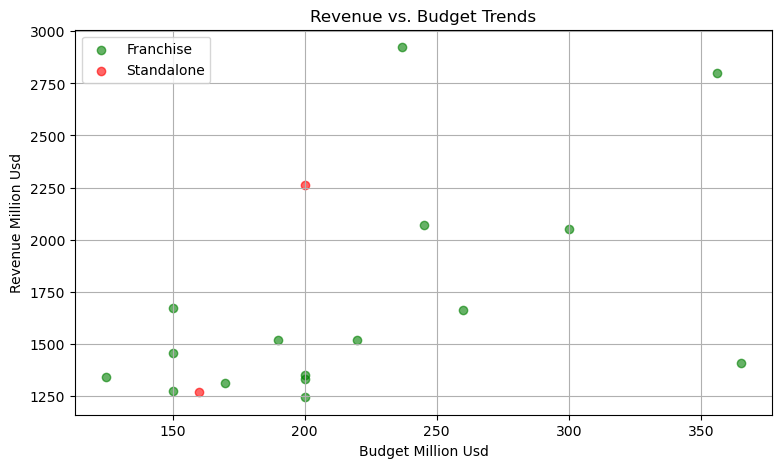

In [7]:
'''Visualize revenue generated vs budget for franchise films and standalones'''

plot_data(df_movies, kind='scatter', x_col='budget_million_usd', y_col='revenue_million_usd')

* Most of the highest revenue points belong to franchise movies
* Standalone films tend to cluster in the lower revenue zone, with only one pushing above the 2B dollars mark
* Some franchise films with very high budgets (300M–350M) didn't perform as well as others with more modest budgets


 <hr>

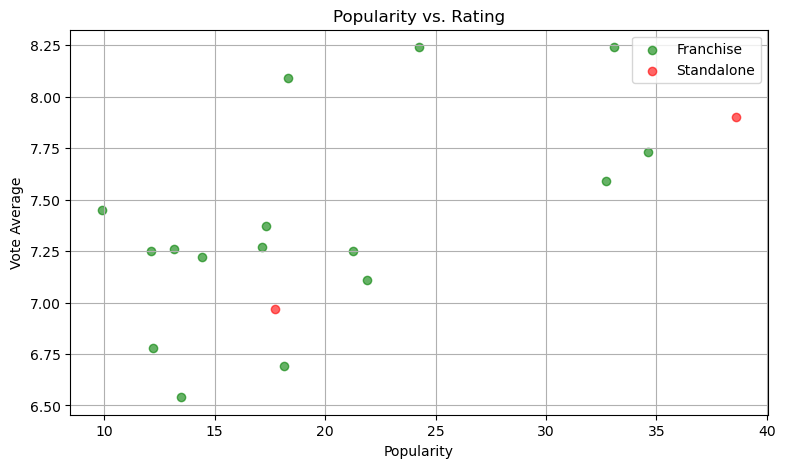

In [8]:
'''Visualize movie Popularity vs Ratings'''
plot_data(
    df_movies, 
    x_col='popularity', 
    y_col='vote_average', 
    title='Popularity vs. Rating'
)

  <hr>

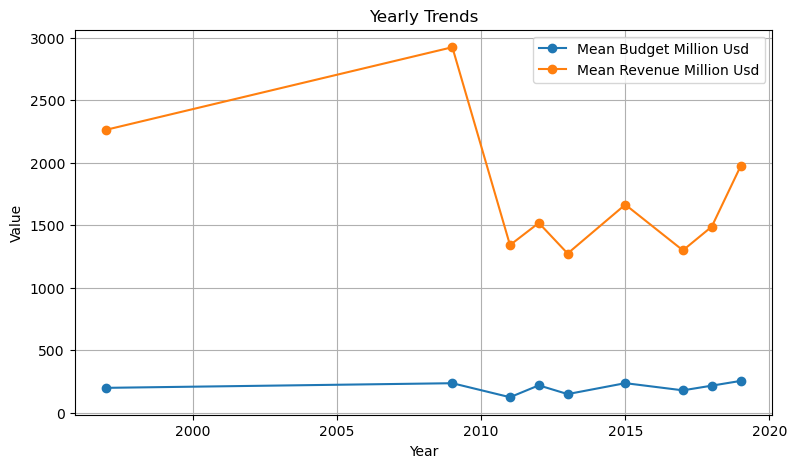

In [9]:
'''Plot the Yearly Trends of movie performance'''

plot_data(df_movies, kind='line', metrics=['budget_million_usd', 'revenue_million_usd'])

<hr>

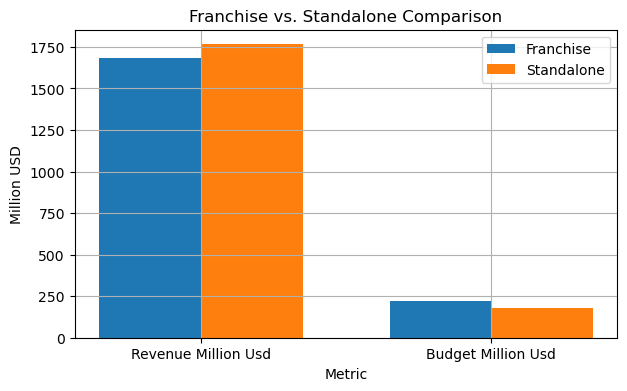

In [11]:
'''Visualize Franchise vs Standalone'''

plot_data(df_movies, kind='bar', metrics=['revenue_million_usd', 'budget_million_usd' ])